# End to End ML Project

In [1]:
from warnings import filterwarnings
filterwarnings("ignore")

## Step 1 - Data ingestion

In [2]:
import pandas as pd
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Target feature is species

In [3]:
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

## Step 2 - Perform basic data quality checks

In [4]:
df.shape

(150, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df.shape

(149, 5)

## Step 3 - Seperate X and Y(species)

In [9]:
X = df.drop(columns=["species"])
Y = df[["species"]]

In [10]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
Y.head()

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [12]:
Y.value_counts()

species   
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

<Axes: xlabel='species'>

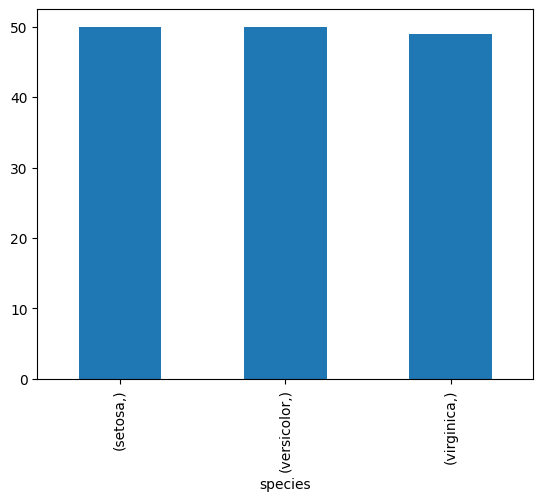

In [13]:
Y.value_counts().plot(kind="bar")

### Step 4 - Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.33, random_state=42)

In [18]:
xtrain.head()

,sepal_length,sepal_width,petal_length,petal_width
95,5.7,3.0,4.2,1.2
104,6.5,3.0,5.8,2.2
66,5.6,3.0,4.5,1.5
0,5.1,3.5,1.4,0.2
141,6.9,3.1,5.1,2.3


In [19]:
ytrain.head()

,species
95,versicolor
104,virginica
66,versicolor
0,setosa
141,virginica


In [20]:
xtest.head()

,sepal_length,sepal_width,petal_length,petal_width
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
117,7.7,3.8,6.7,2.2
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4


In [21]:
ytest.head()

,species
73,versicolor
18,setosa
117,virginica
78,versicolor
76,versicolor


In [22]:
xtrain.shape

(99, 4)

In [23]:
xtest.shape

(50, 4)

### Step 5 - Preprocessing and Model building pipline

In [24]:
X.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [26]:
pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression()
)

In [27]:
pipeline.fit(xtrain, ytrain)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

### Step 6 - Model Evaluation

In [28]:
pipeline.score(xtrain, ytrain)

0.9494949494949495

In [29]:
pipeline.score(xtest, ytest)

1.0

In [30]:
ypred_test = pipeline.predict(xtest)
ypred_test[0:5]

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor'],
      dtype=object)

In [31]:
ytest.head()

,species
73,versicolor
18,setosa
117,virginica
78,versicolor
76,versicolor


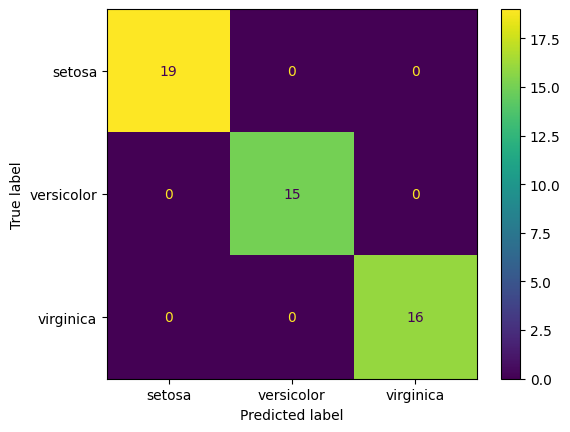

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipeline, xtest, ytest)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(ytest, ypred_test))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



### Cross validation

In [34]:
from sklearn.model_selection import cross_val_score

In [35]:
scores = cross_val_score(pipeline, xtrain, ytrain, cv=5, scoring="f1_macro", n_jobs=-1)
scores

array([0.95213675, 0.80952381, 0.90277778, 1.        , 0.94747475])

In [36]:
scores.mean()

np.float64(0.9223826173826174)

### Form above evaluation , i can say that model is good for out of sample prediction

### Step 7 - Save the model object

In [37]:
pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [38]:
import joblib

joblib.dump(pipeline, "pipeline.joblib")

['pipeline.joblib']

### Loading model object

In [39]:
m = joblib.load("pipeline.joblib")
m

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

### Predicting out of sample data from user input

In [40]:
xtrain.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [41]:
pipeline.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [46]:
def predict_results(sep_len, sep_wid, pet_len, pet_wid):
    # Convert the results to dataframe
    inputs = [
        {
            "sepal_length": sep_len,
            "sepal_width": sep_wid,
            "petal_length": pet_len,
            "petal_width": pet_wid
        }
    ]
    xnew = pd.DataFrame(inputs)
    preds = pipeline.predict(xnew)
    probs = pipeline.predict_proba(xnew).flatten()
    classes = pipeline.classes_
    probs_dict = dict(zip(classes, probs.round(4)))
    return preds[0], probs_dict

In [47]:
predict_results(sep_len=4, sep_wid=3, pet_len=2, pet_wid=1)

('setosa',
 {'setosa': np.float64(0.929),
  'versicolor': np.float64(0.0709),
  'virginica': np.float64(0.0001)})

In [48]:
predict_results(6.3, 2.5, 4.9, 1.5)

('versicolor',
 {'setosa': np.float64(0.0013),
  'versicolor': np.float64(0.5514),
  'virginica': np.float64(0.4473)})